In [1]:
# NumPy를 np라는 별칭으로 불러오고, 표준 정규분포에서 4×4 크기의 난수 표본을 생성합니다.
# 실행할 때마다 samples의 값은 달라집니다.
import numpy as np
samples = np.random.normal(size=(4, 4))

In [2]:
# 앞 셀에서 생성한 4×4 정규분포 난수 배열의 값을 확인합니다.
samples

array([[-0.13046571, -0.40553397, -1.38576284,  1.89890344],
       [-0.89764467, -2.04336535,  0.04995669, -0.45323422],
       [ 1.07328512,  1.89584035, -2.02064806, -0.29786178],
       [-1.16412266,  1.12376086, -0.15671196, -1.06922568]])

In [3]:
# 파이썬 표준 라이브러리 random을 불러와 0, 1, 2 중 하나를 무작위로 선택합니다.
# randint(a, b)는 NumPy와 달리 끝값 b도 선택 범위에 포함합니다.
import random 
a = random.randint(0,2)                                                     #0,1,2 중에 하나 랜덤 선택
a

1

In [4]:
# 시작 위치를 0으로 두고, 매 단계마다 +1 또는 -1만큼 이동하는 랜덤 워크를 만듭니다.
# 초기 위치까지 저장하므로 walk에는 총 1,001개의 위치가 기록됩니다.
import random
position = 0
walk = [position]
steps = 1000
for i in range(steps):
    step = 1 if random.randint(0,1) else -1
    position += step
    walk.append(position)

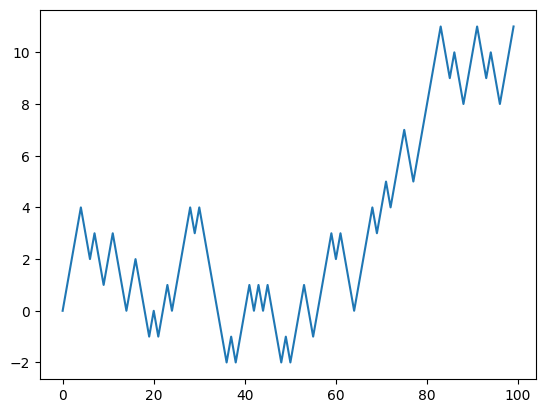

In [5]:
# Matplotlib을 불러와 랜덤 워크의 초기 100개 위치를 선 그래프로 그립니다.
import matplotlib.pyplot as plt
plt.plot(walk[:100])

In [16]:
# NumPy의 randint로 0 또는 1 중 하나를 무작위로 생성합니다.
# 이 함수의 상한 2는 범위에 포함되지 않습니다.
np.random.randint(0,2)                                                      #0,1 중에 하나 랜덤 선택

1

In [17]:
# 0과 1로 이루어진 난수 1,000개를 만든 뒤, np.where로 각각 -1과 +1의 이동량으로 변환합니다.
draws = np.random.randint(0, 2, size=1000)
steps = np.where(draws>0, 1, -1)                                            #조건 draws > 0이 참이면 1, 거짓이면 -1을 선택합니다.
# draws와 steps 배열 앞 20개씩 보여주기
draws[:20], steps[:20]

(array([1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1]),
 array([ 1,  1,  1, -1, -1,  1, -1,  1, -1, -1, -1, -1,  1, -1, -1,  1, -1,
         1,  1,  1]))

In [19]:
# 각 이동량을 처음부터 누적 합산하여 매 시점의 위치를 계산합니다.
# cumsum()의 결과 walk에는 1,000개 시점의 위치가 저장됩니다.
walk = steps.cumsum()
walk[:20]

array([ 1,  2,  3,  2,  1,  2,  1,  2,  1,  0, -1, -2, -1, -2, -3, -2, -3,
       -2, -1,  0])

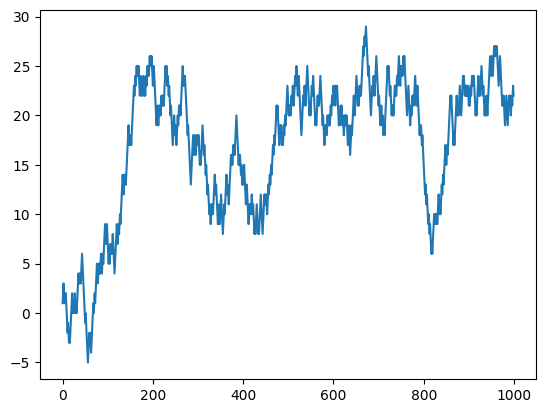

In [20]:
# NumPy로 계산한 1,000단계 랜덤 워크 전체를 선 그래프로 시각화합니다.
plt.plot(walk)

In [24]:
# 랜덤 워크가 도달한 위치 중 최솟값과 최댓값을 구합니다.
print(walk.min())
print(walk.max())

-5
29


In [25]:
# 위치의 절댓값이 처음으로 10 이상이 된 시점의 인덱스를 찾습니다.
# argmax()는 첫 True의 위치를 반환하지만, 조건을 한 번도 만족하지 않으면 0을 반환하므로 주의해야 합니다.
(np.abs(walk)>=10).argmax()

np.int64(127)

In [29]:
# 1,000단계 랜덤 워크를 5,000개 동시에 시뮬레이션하기 위한 0/1 난수 행렬을 생성합니다.
# 각 행은 하나의 랜덤 워크, 각 열은 해당 워크의 한 시점을 뜻합니다.
nwalks = 5000
nsteps = 1000
draws = np.random.randint(0,2, size=(nwalks, nsteps))
print(draws)
print(draws.shape)                                                          #난수 행렬의 크기 확인

[[0 0 1 ... 1 1 1]
 [0 1 0 ... 0 0 0]
 [0 1 1 ... 1 0 0]
 ...
 [1 1 0 ... 1 0 1]
 [1 0 0 ... 0 1 1]
 [0 1 0 ... 1 1 1]]
(5000, 1000)


In [30]:
# 0/1 난수 행렬을 -1/+1 이동량 행렬로 변환합니다.
# 주석 처리된 코드는 이동량을 평균 0, 표준편차 0.25인 정규분포로 생성하는 대안입니다.
steps = np.where(draws>0, 1, -1)
#steps = np.random.normal(loc=0, scale=0.25, size=(nwalks, nsteps))
steps

array([[-1, -1,  1, ...,  1,  1,  1],
       [-1,  1, -1, ..., -1, -1, -1],
       [-1,  1,  1, ...,  1, -1, -1],
       ...,
       [ 1,  1, -1, ...,  1, -1,  1],
       [ 1, -1, -1, ..., -1,  1,  1],
       [-1,  1, -1, ...,  1,  1,  1]], shape=(5000, 1000))

In [31]:
# 열 방향(axis=1)으로 이동량을 누적해 5,000개 랜덤 워크의 시점별 위치를 계산합니다.
# walks의 각 행에는 하나의 완전한 랜덤 워크가 저장됩니다.
walks = steps.cumsum(1)
walks

array([[ -1,  -2,  -1, ...,  20,  21,  22],
       [ -1,   0,  -1, ...,  18,  17,  16],
       [ -1,   0,   1, ..., -22, -23, -24],
       ...,
       [  1,   2,   1, ...,  30,  29,  30],
       [  1,   0,  -1, ..., -58, -57, -56],
       [ -1,   0,  -1, ...,  14,  15,  16]], shape=(5000, 1000))

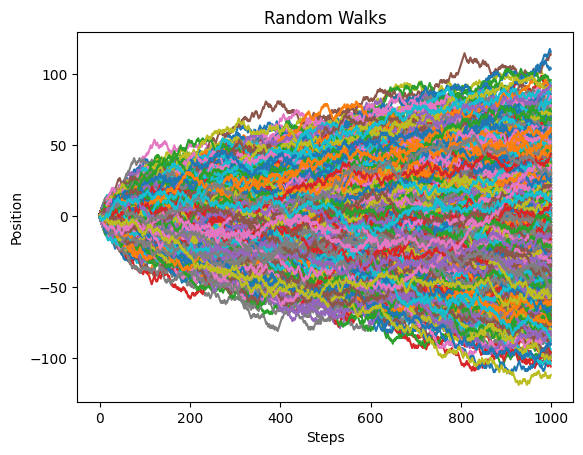

In [33]:
# 2차원 배열 walks를 선 그래프로 그려 여러 랜덤 워크의 변화를 확인합니다.
# Matplotlib은 기본적으로 각 열을 하나의 선으로 해석하므로, 행별 워크를 그리려면 walks.T를 사용할 수 있습니다.
plt.plot(walks.T)
plt.title('Random Walks')
plt.xlabel('Steps')
plt.ylabel('Position')
plt.show()

In [34]:
# 5,000개 랜덤 워크의 모든 위치를 통틀어 가장 큰 값과 가장 작은 값을 구합니다.
print(walks.max())
print(walks.min())

118
-119


In [37]:
# 각 랜덤 워크가 한 번이라도 절댓값 30 이상에 도달했는지 검사합니다.
# any(1)은 각 행의 1,000개 시점을 확인하여 워크별 True/False 값을 반환합니다.
hist30 = (np.abs(walks)>=30).any(1)                                         #열 방향 검토
print(hist30)
print(hist30.shape)

[ True  True  True ...  True  True False]
(5000,)


In [38]:
# 절댓값 30 이상에 도달한 워크만 골라, 각 워크의 최초 도달 시점 인덱스를 구합니다.
# hist30으로 이미 도달 여부를 걸렀으므로 argmax(1)는 각 행에서 처음 True인 열 위치를 안전하게 반환합니다.
crossing_times = (np.abs(walks[hist30])>=30).argmax(1)                      #argmax(1)은 각 행에서 처음 True인 열 위치를 반환합니다.
crossing_times

array([723, 191, 919, ..., 937, 541, 203], shape=(3409,))

In [ ]:
# 추가 NumPy 랜덤 워크 분석을 자유롭게 실습하기 위한 빈 셀입니다.